In [ ]:
import numpy as np 
import pandas as pd
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from stengression import GCEN, STEN, MVEN, GraphInfo, SpatioTemporalDataset 
from stengression import compute_adjacency_matrix, prepare_spatial_weights, plot_forecasts, energy_score_loss

## 1. Prepare the distances and adjacency matrix

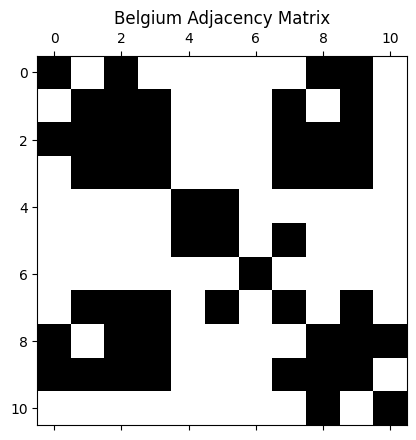

Number of nodes: 11, Number of edges: 49


In [3]:
# Load the matrix containing Haversine distances for each node and compute the adjacency matrix
distances = pd.read_csv("Belgium_Distance_Matrix.csv")
dist_array = distances.values
adjacency_matrix = compute_adjacency_matrix(distances.values, sigma2=0.9948808074595779, epsilon=0.07692416606625796, n=40)
np.fill_diagonal(adjacency_matrix, 1)
plt.spy(adjacency_matrix)
plt.title("Belgium Adjacency Matrix")
plt.show()

node_indices, neighbor_indices = np.where(adjacency_matrix == 1)
graph_info = GraphInfo(
    edges=(node_indices.tolist(), neighbor_indices.tolist()),
    num_nodes=adjacency_matrix.shape[0],
)
print(f"Number of nodes: {graph_info.num_nodes}, Number of edges: {len(graph_info.edges[0])}")

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
graph_conv_params = {
                "aggregation_type": "mean", # mean, sum, max
                "combination_type": "concat",
                "activation": None
            }
gcn_seed = 21
temporal_seed = 9
print(f'Using device: {device}.')

Using device: cuda.


## 2. Prepare the training dataset

In [6]:
# Forecast horizon: 30 days
NUM_NODES = 11
IN_FEAT_DIM = 1   # D

P_LAG = 60        # Lag window, input_seq_len
T_PRED = 30        # Prediction horizon, output_seq_len
BATCH_SIZE = 64

alpha, max_spatial_lag = 1,2 
W = 1/(dist_array**alpha)
np.fill_diagonal(W, 0)
row_sums = W.sum(axis=1, keepdims=True)
W = W / row_sums
W = torch.tensor(W)
# W is the initial spatial weights matrix

W_list = prepare_spatial_weights(W, max_lag=max_spatial_lag)

df = pd.read_csv("Belgium_Covid_Nodates.csv", encoding='latin-1')
sts_data = torch.tensor(df.values, dtype=torch.float32)
sts_data=sts_data.view(sts_data.shape[0], sts_data.shape[1], 1) # Converts into T x N x 1
sts_data.to(device)
node_names = df.columns.tolist()

train_tensor = sts_data[:-T_PRED, :, :]
test_ground_truth = sts_data[-T_PRED:, :, :] # The ground truth for the first forecast window is the first T_PRED steps of the test set
test_history = train_tensor[-P_LAG:, :, :] # The history required to make this forecast is the last P_LAG steps of the training set

# Standardize train data
y_train = train_tensor.clone()
mean, std = train_tensor.mean(axis=0), train_tensor.std(axis=0)
train_tensor = ((train_tensor - mean) / std)
test_history = ((test_history - mean) / std) 

# Caution: Do not standardize test_ground_truth, as we want to compare the real forecast values. 
train_dataset = SpatioTemporalDataset(train_tensor, input_seq_len=P_LAG, output_seq_len=T_PRED, multi_horizon=True)
trainloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)

## 3. MVEN

### 3.1 Training the MVEN model

Training: 100%|██████████| 100/100 [00:30<00:00,  3.32epoch/s]


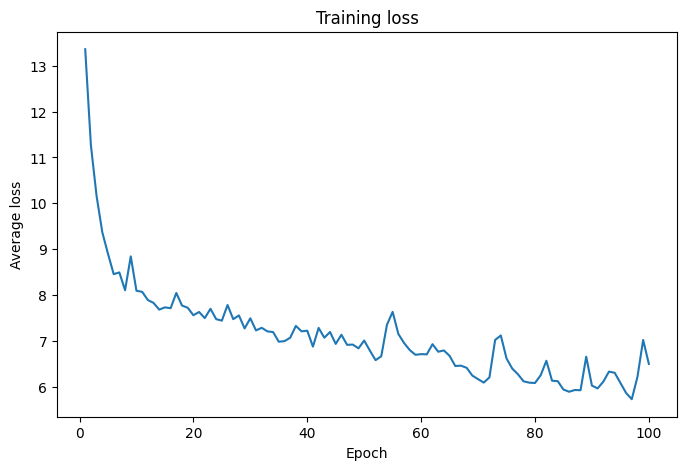

In [7]:
mven = MVEN(in_feat_dim=IN_FEAT_DIM, 
           lstm_hidden_dim=72, lstm_num_layers=3, 
            lstm_dropout=0.09462213176635498, noise_dist="uniform",
           p_lag=P_LAG, t_pred=T_PRED, 
            num_nodes=NUM_NODES, temporal_seed=9).to(device)
optimizer = optim.Adam(mven.parameters(), lr=0.00440078425059993) 

# Run Training
mven.fit(data_loader=trainloader, optimizer=optimizer, loss_fn=energy_score_loss, num_epochs=100, m_samples=2, 
         device=device, monitor=True, visualize=True, verbose=False)

### 3.2 In-sample Diagnostics

In [8]:
# Getting the un-standardized in-sample predictions
in_sample_preds = mven.predict_in_sample(train_tensor, m_samples = 100, method = "q_step", batch_size = 64, 
                                         device=device, unstandardize=[mean, std])

in_sample_preds.shape

torch.Size([100, 746, 11, 1])

In [9]:
# Evaluation of in-sample predictions
mven.evaluate_in_sample_fit(train_tensor, m_samples = 100, n_repeats = 10,
        method = "q_step", batch_size = 64, point_method="median",
        unstandardize = [mean,std], device = device)

,SMAPE,MAE,RMSE,MASE,RMSSE,Pinball_80,Pinball_95,Rho-0.5,Rho-0.9,CRPS,EC,Winkler
mean,67.11,224.55,565.75,1.15,1.15,111.72,85.06,0.46,0.4,185.68,0.54,4278.32
std,0.11,0.61,2.43,0.00,0.00,0.45,0.60,0.00,0.0,0.29,0.00,32.22


In [10]:
# Getting the residuals
residuals = mven.get_residuals(in_sample_preds, y_train, point_method="median")
residuals.shape

torch.Size([746, 11, 1])

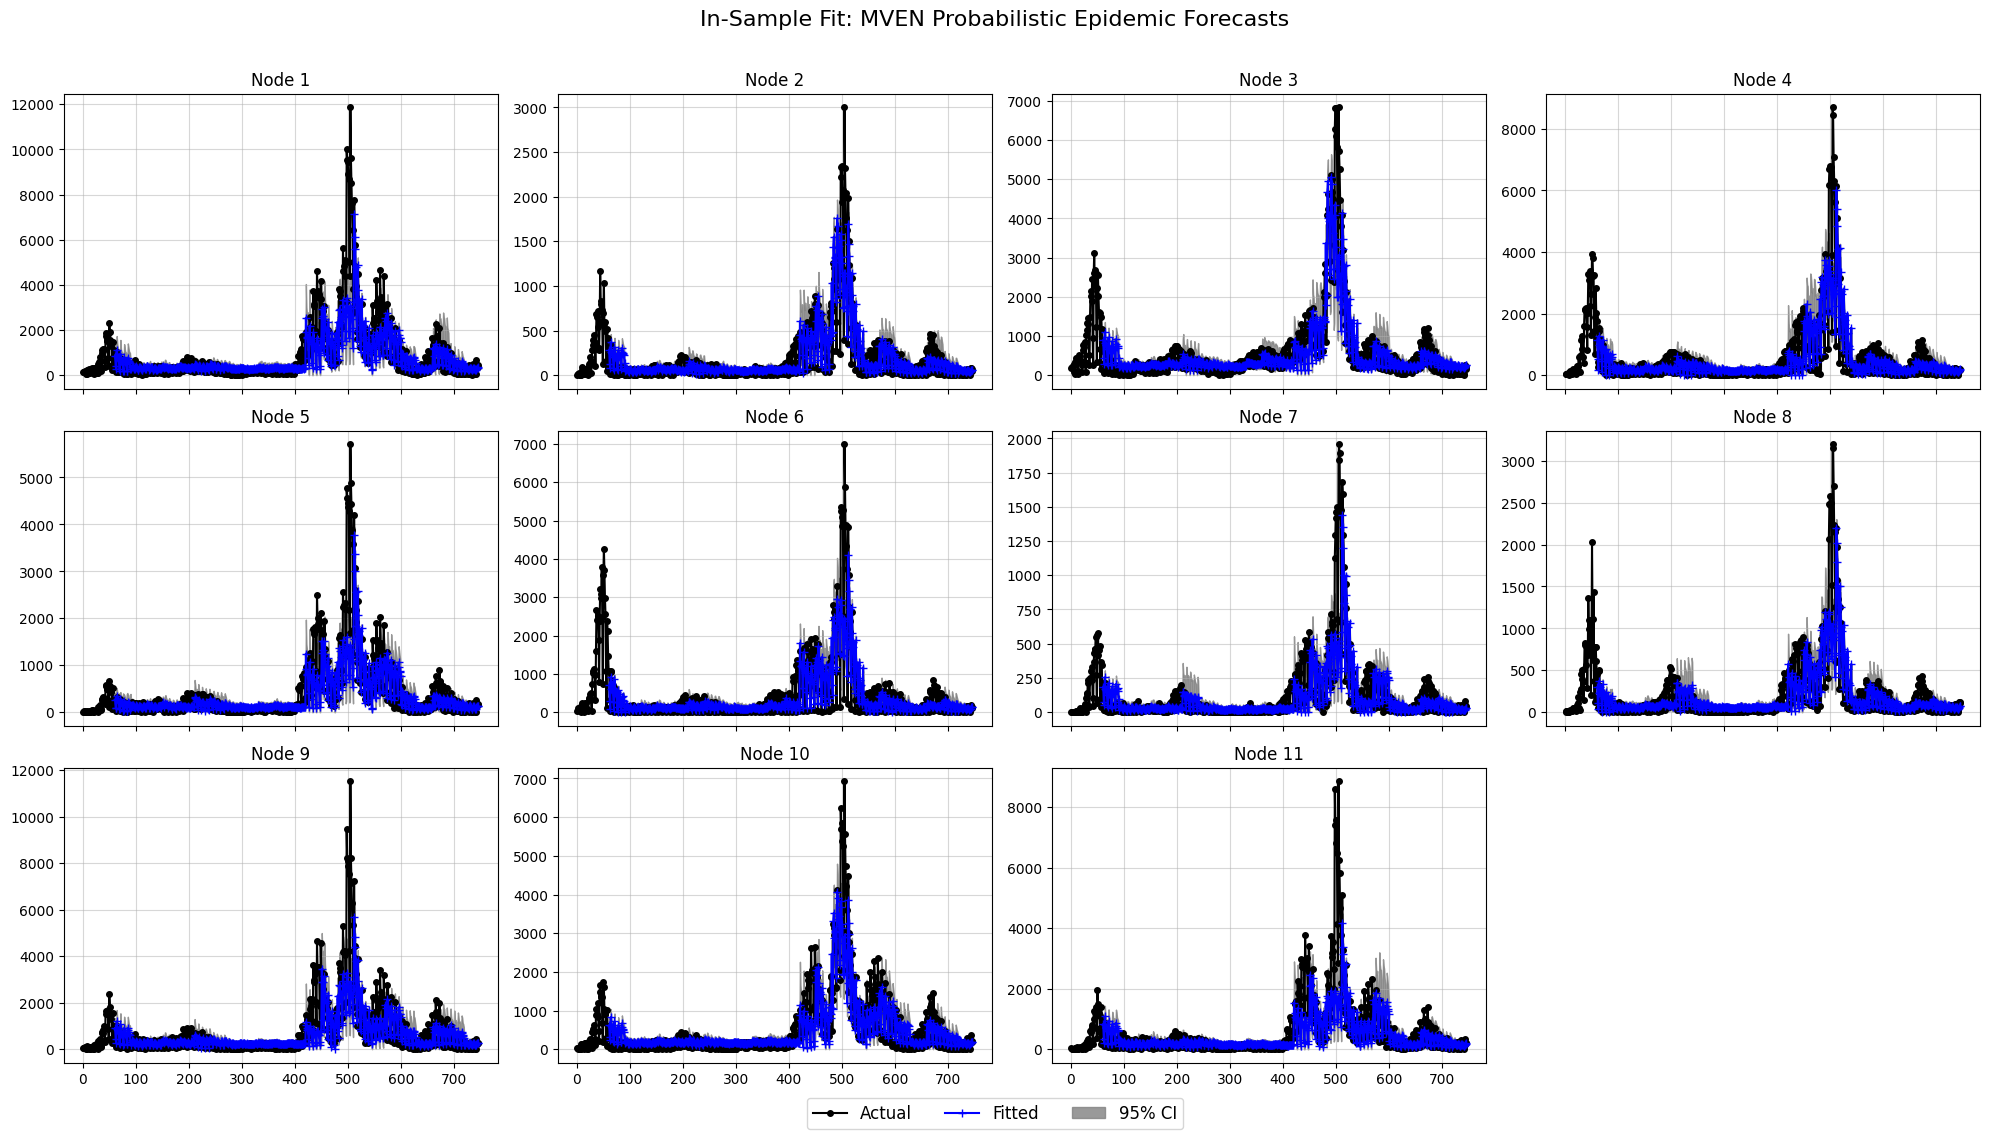

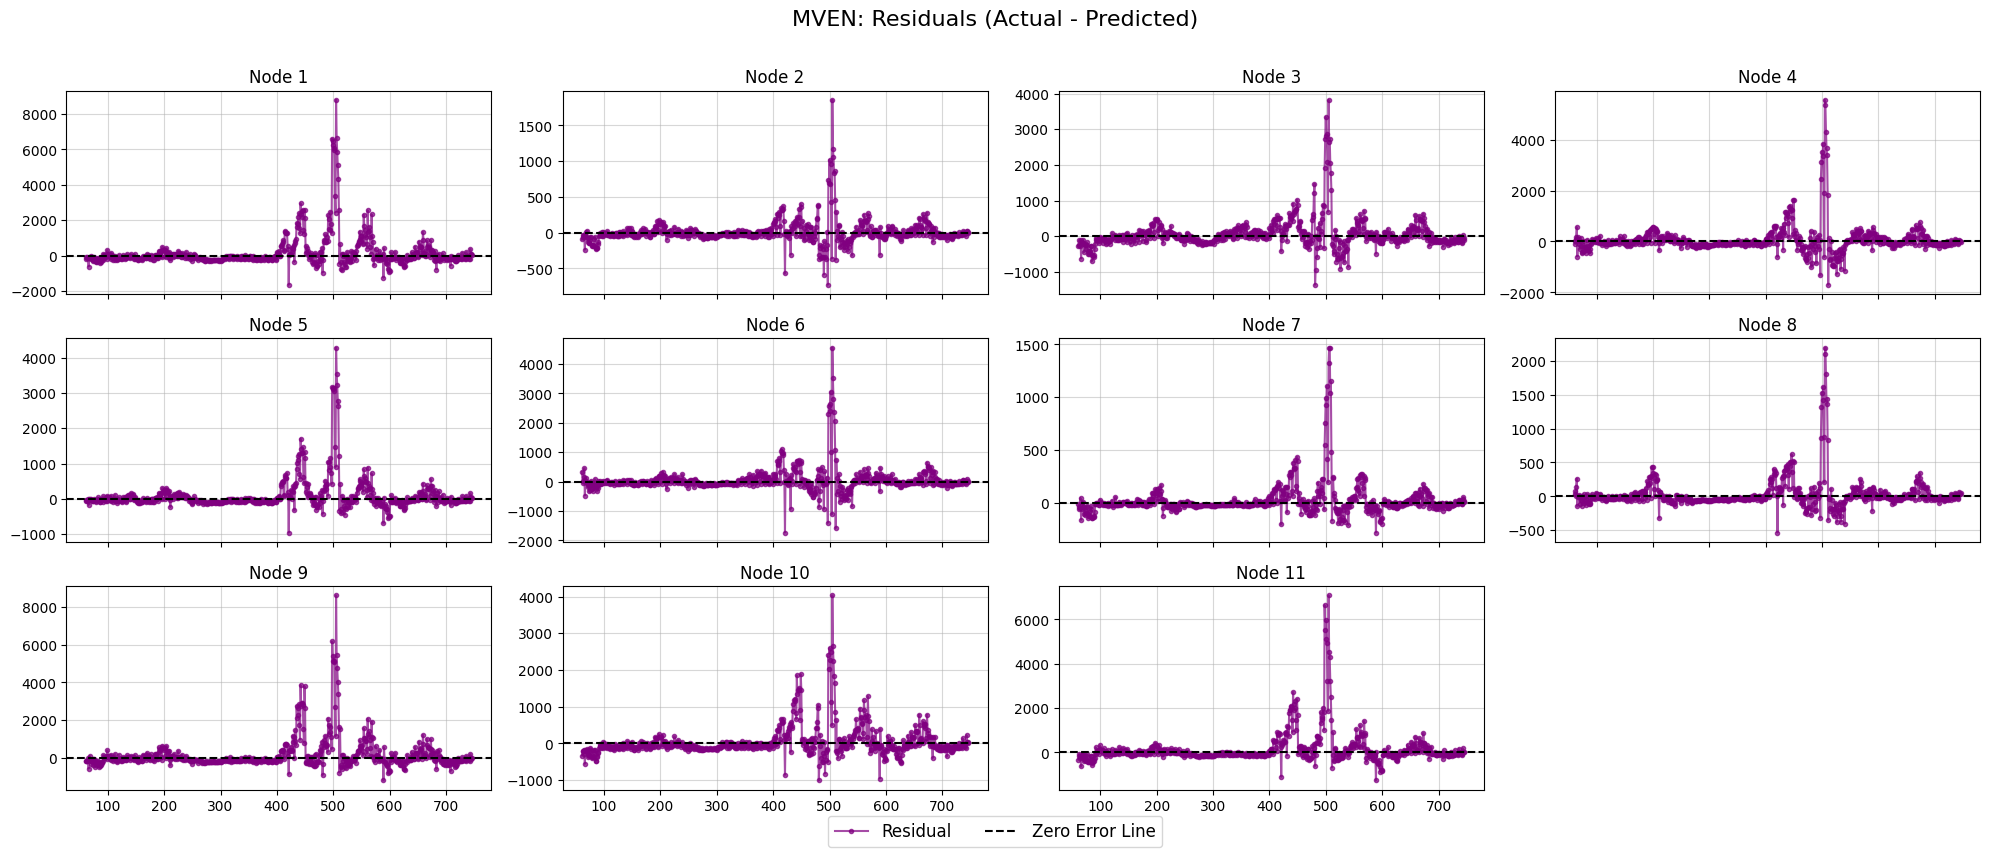

In [11]:
# Plotting the in-sample predictions vs training data and residuals
mven.plot_in_sample_fit(
    in_sample_preds=in_sample_preds,
    original_data=y_train, # Ensure ground truth is also in original scale
    plots_per_row=4,
    confidence_level=0.95,
    title="In-Sample Fit: MVEN Probabilistic Epidemic Forecasts"
)

mven.plot_residuals(
    residuals=residuals,
    plots_per_row=4,
    title="MVEN: Residuals (Actual - Predicted)"
)

### 3.3 Out-of-sample Forecasts and Evaluation

In [16]:
forecast_ensemble = mven.predict(m_samples=100, history=test_history, unstandardize=[mean, std], device=device)
forecast_ensemble.shape

torch.Size([100, 30, 11, 1])

In [18]:
metrics = mven.evaluate_forecasts(m_samples=100, n_repeats=50, 
                              history=test_history, y_true=test_ground_truth, y_train=y_train, 
                              unstandardize=[mean, std])
metrics

,SMAPE,MAE,RMSE,MASE,RMSSE,Pinball_80,Pinball_95,Rho-0.5,Rho-0.9,CRPS,EC,Winkler
mean,66.41,95.81,127.96,0.49,0.26,35.56,15.81,0.54,0.27,72.87,0.62,1140.36
std,0.43,0.85,1.21,0.00,0.00,0.69,0.83,0.00,0.01,0.67,0.01,32.17


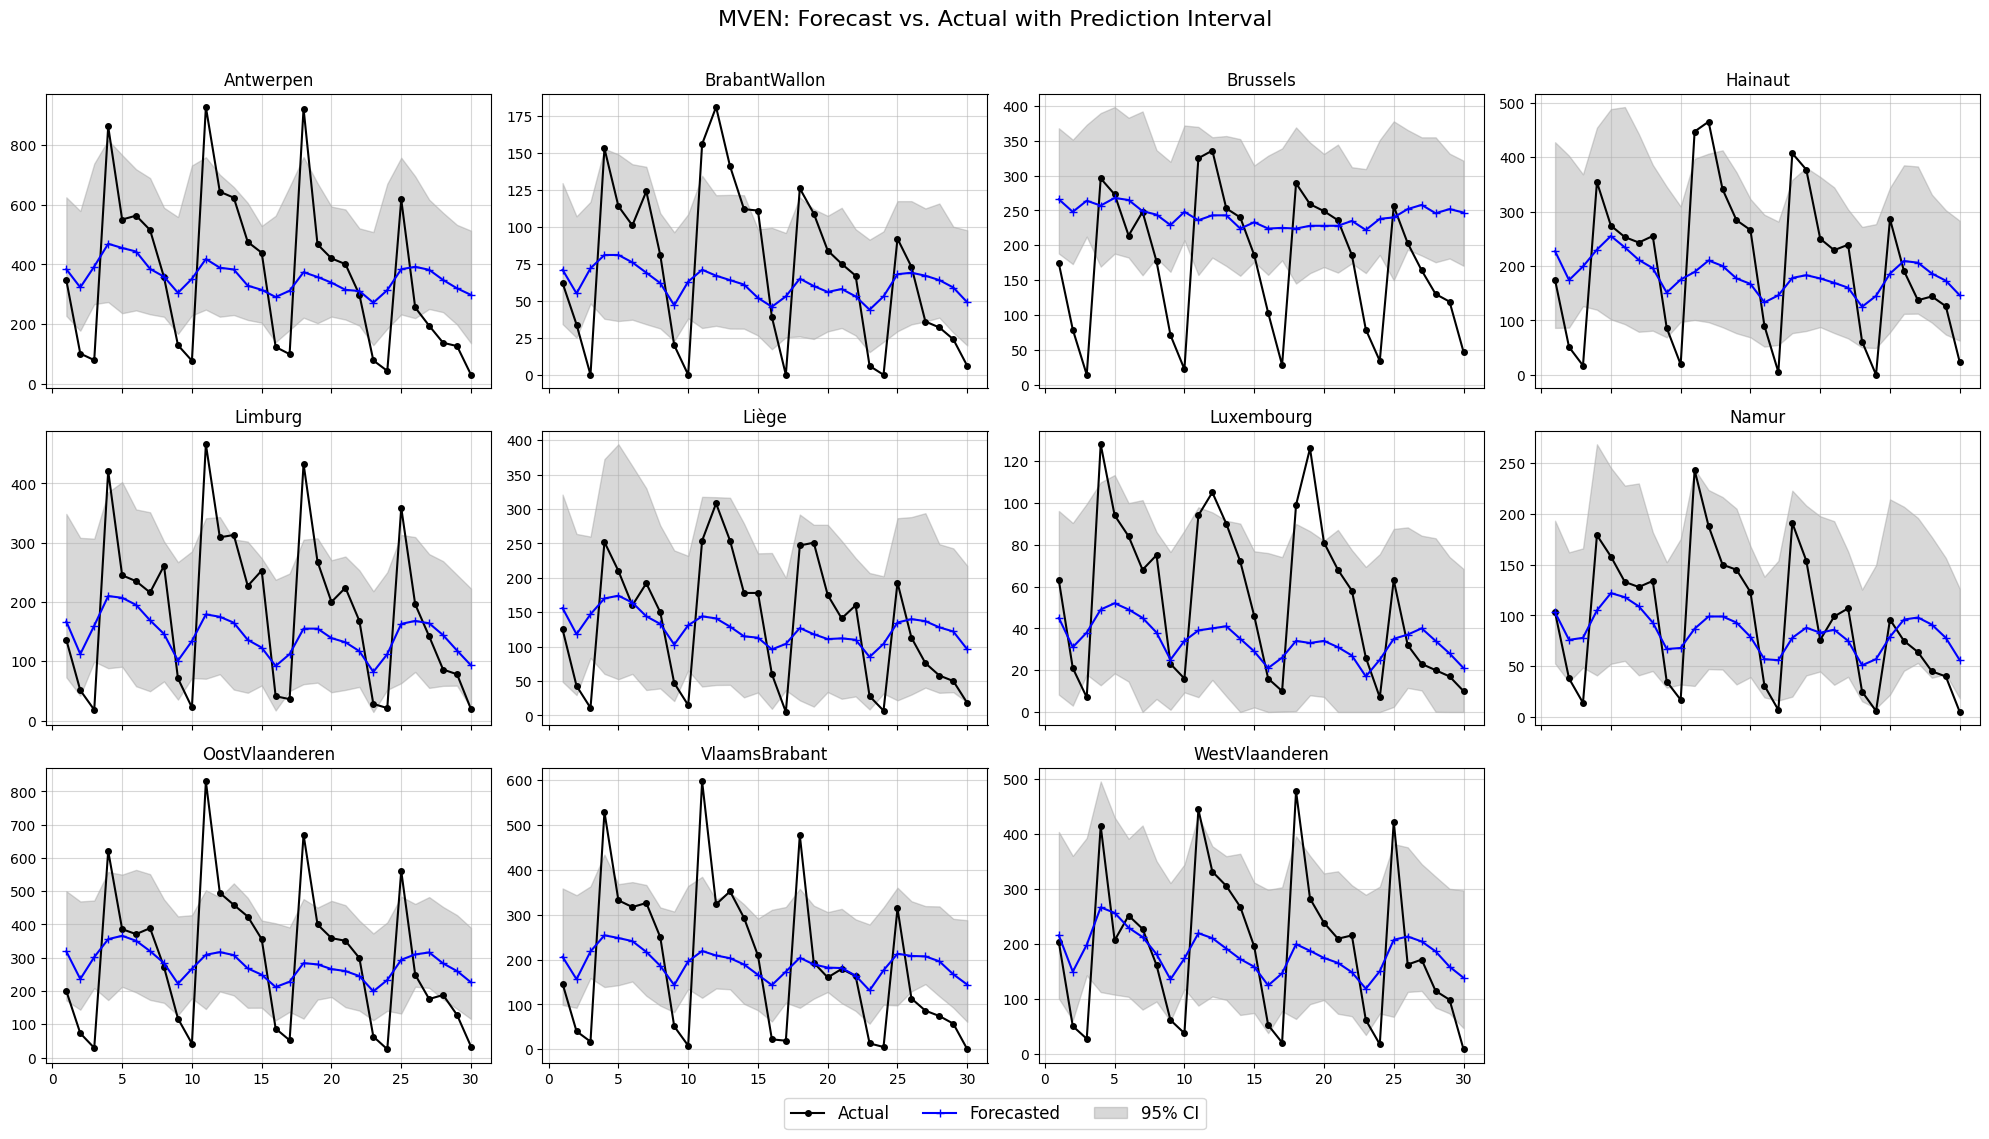

In [ ]:
forecast_ensemble = mven.predict(test_history, m_samples = 100, unstandardize=[mean, std], device=device)
plot_forecasts(NUM_NODES, plots_per_row=4, t_pred=30, forecast_ensemble=forecast_ensemble, 
               ground_truth=test_ground_truth, confidence_level=0.95, node_names=node_names,
                   title='MVEN: Forecast vs. Actual with Prediction Interval')

## 4. GCEN

### 4.1 Training the GCEN Model

Training: 100%|██████████| 100/100 [01:03<00:00,  1.56epoch/s]


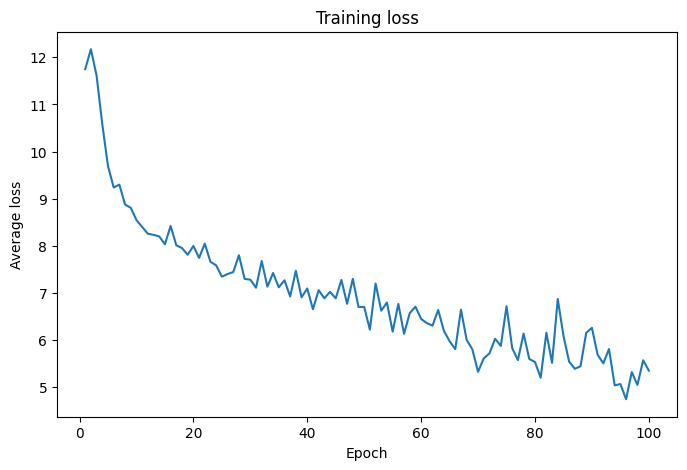

In [24]:
gcen = GCEN(in_feat_dim=IN_FEAT_DIM,
    gcn_out_feat=6,
    lstm_hidden_dim=91,
    lstm_num_layers=5,
    lstm_dropout=0.30479293048737066,
    p_lag=P_LAG,
    t_pred=T_PRED,
    graph_info=graph_info,
    graph_conv_params=graph_conv_params,
    noise_encode="add",
    noise_dist="uniform",
    gcn_seed=21,
    temporal_seed=9
).to(device)
optimizer = optim.Adam(gcen.parameters(), lr=0.00426979947571805) 

# Run Training
gcen.fit(data_loader=trainloader, optimizer=optimizer, loss_fn=energy_score_loss, num_epochs=100, m_samples=2, 
         device=device, monitor=True, visualize=True, verbose=False)

### 4.2 In-sample Diagnostics

In [28]:
# Getting the un-standardized in-sample predictions
in_sample_preds = gcen.predict_in_sample(train_tensor, m_samples = 100, method = "q_step", batch_size = 64, 
                                         device=device, unstandardize=[mean, std])

in_sample_preds.shape

torch.Size([100, 746, 11, 1])

In [29]:
# Evaluation of in-sample predictions
gcen.evaluate_in_sample_fit(train_tensor, m_samples = 100, n_repeats = 10,
        method = "q_step", batch_size = 64, point_method="median",
        unstandardize = [mean,std], device = device)

,SMAPE,MAE,RMSE,MASE,RMSSE,Pinball_80,Pinball_95,Rho-0.5,Rho-0.9,CRPS,EC,Winkler
mean,63.87,202.47,517.36,1.03,1.05,110.0,88.85,0.42,0.41,169.35,0.55,4072.27
std,0.12,0.68,3.54,0.00,0.01,0.5,0.74,0.00,0.00,0.50,0.00,46.93


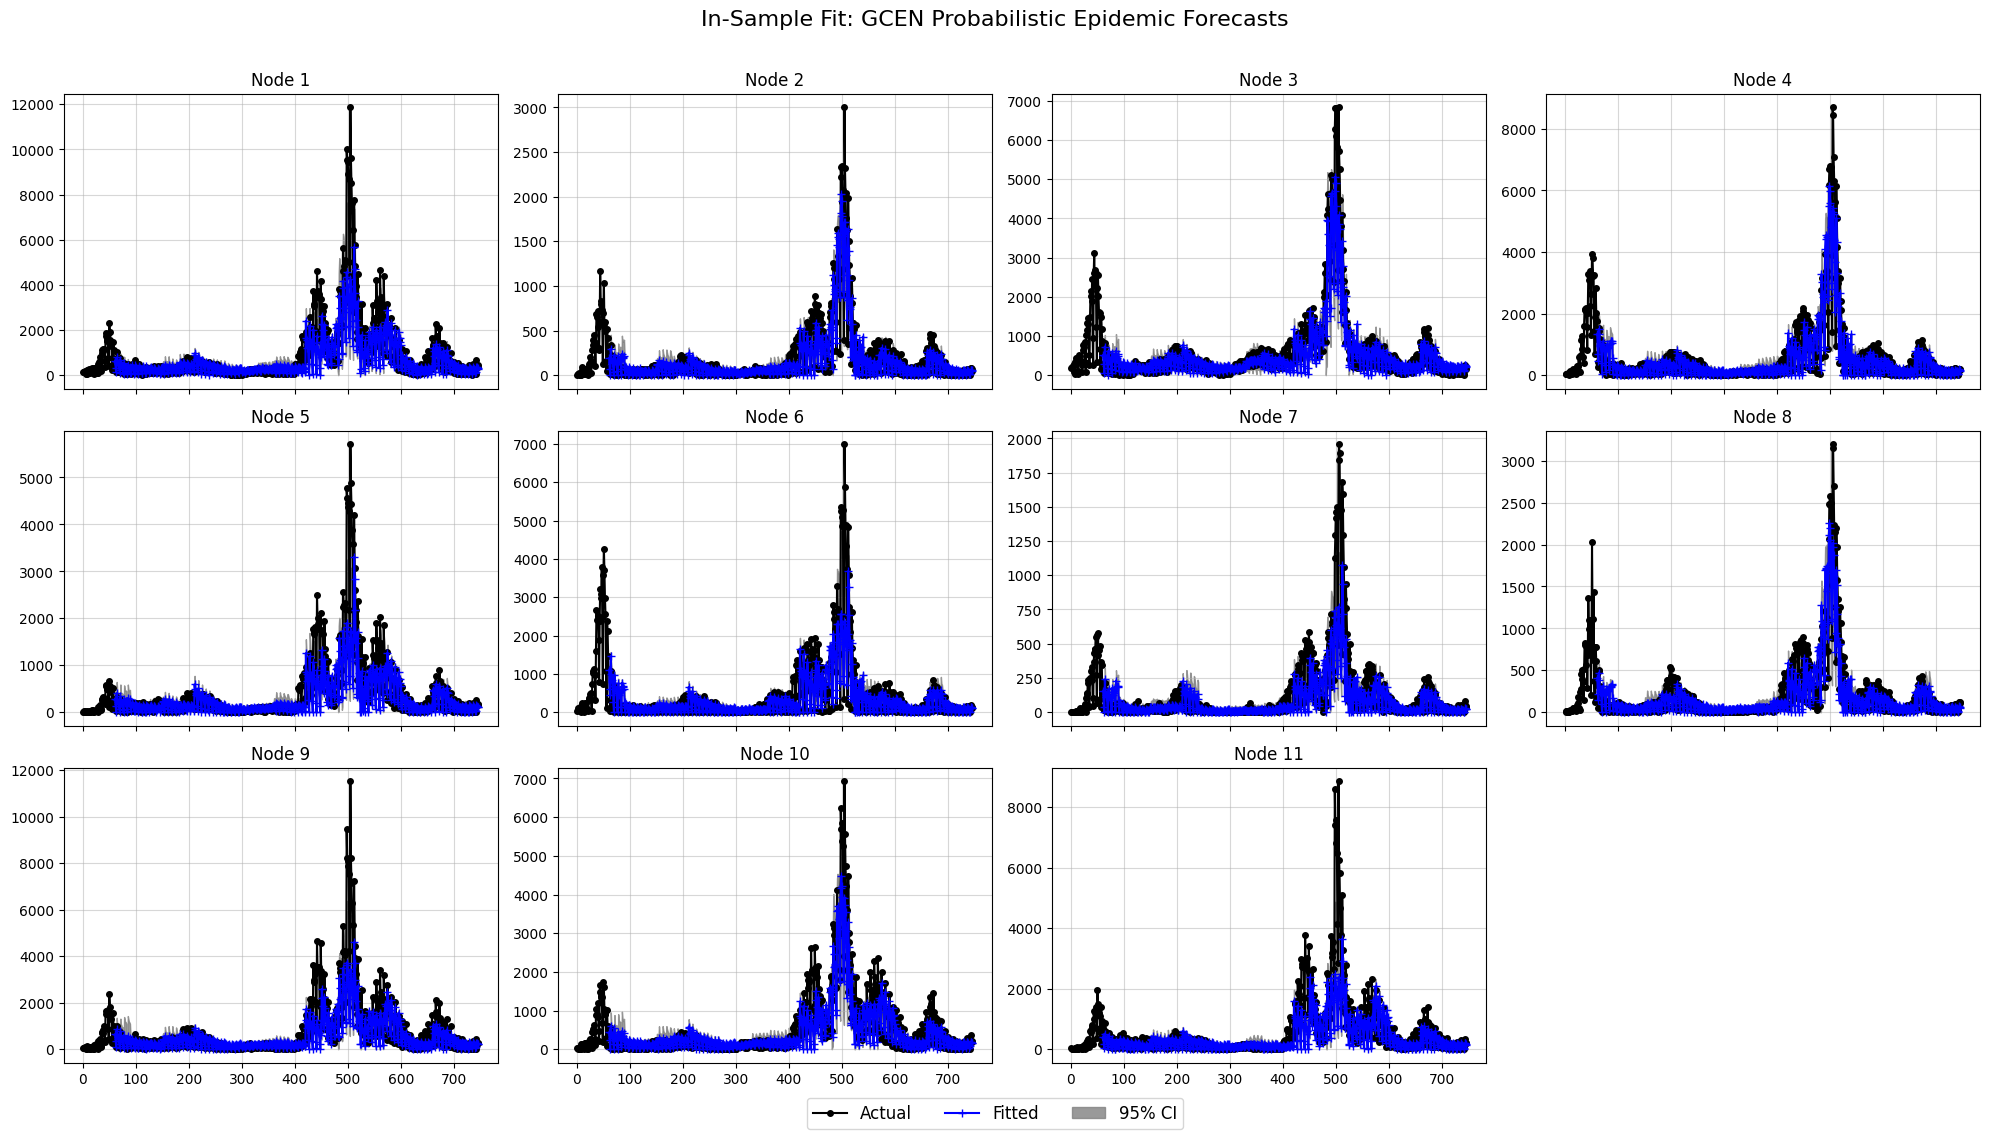

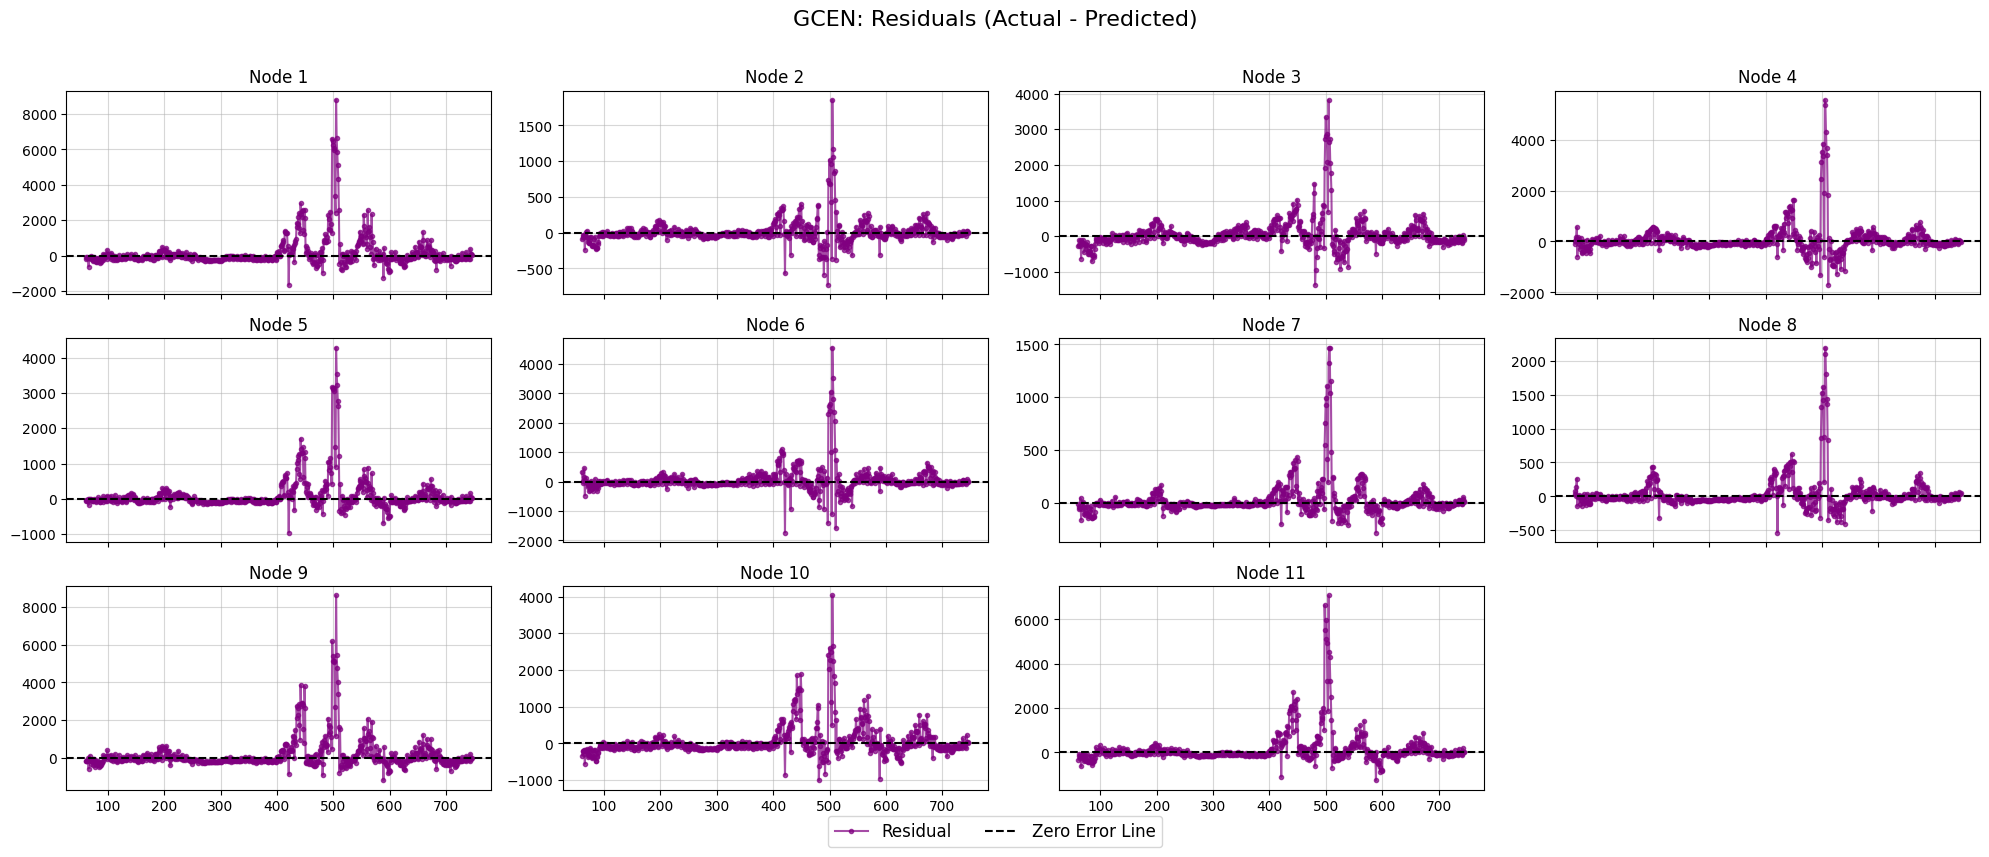

In [30]:
# Plotting the in-sample predictions vs training data and residuals
gcen.plot_in_sample_fit(
    in_sample_preds=in_sample_preds,
    original_data=y_train, # Ensure ground truth is also in original scale
    plots_per_row=4,
    confidence_level=0.95,
    title="In-Sample Fit: GCEN Probabilistic Epidemic Forecasts"
)

gcen.plot_residuals(
    residuals=residuals,
    plots_per_row=4,
    title="GCEN: Residuals (Actual - Predicted)"
)

### 4.2 Out-of-sample Forecasts and Evaluation

In [25]:
metrics = gcen.evaluate_forecasts(m_samples=100, n_repeats=50, 
                              history=test_history, y_true=test_ground_truth, y_train=y_train, 
                              unstandardize=[mean, std])
display(metrics)

,SMAPE,MAE,RMSE,MASE,RMSSE,Pinball_80,Pinball_95,Rho-0.5,Rho-0.9,CRPS,EC,Winkler
mean,46.99,55.13,82.02,0.28,0.17,22.2,10.17,0.31,0.18,42.38,0.86,561.29
std,1.08,0.86,1.44,0.00,0.00,0.6,0.32,0.00,0.00,0.59,0.01,14.58


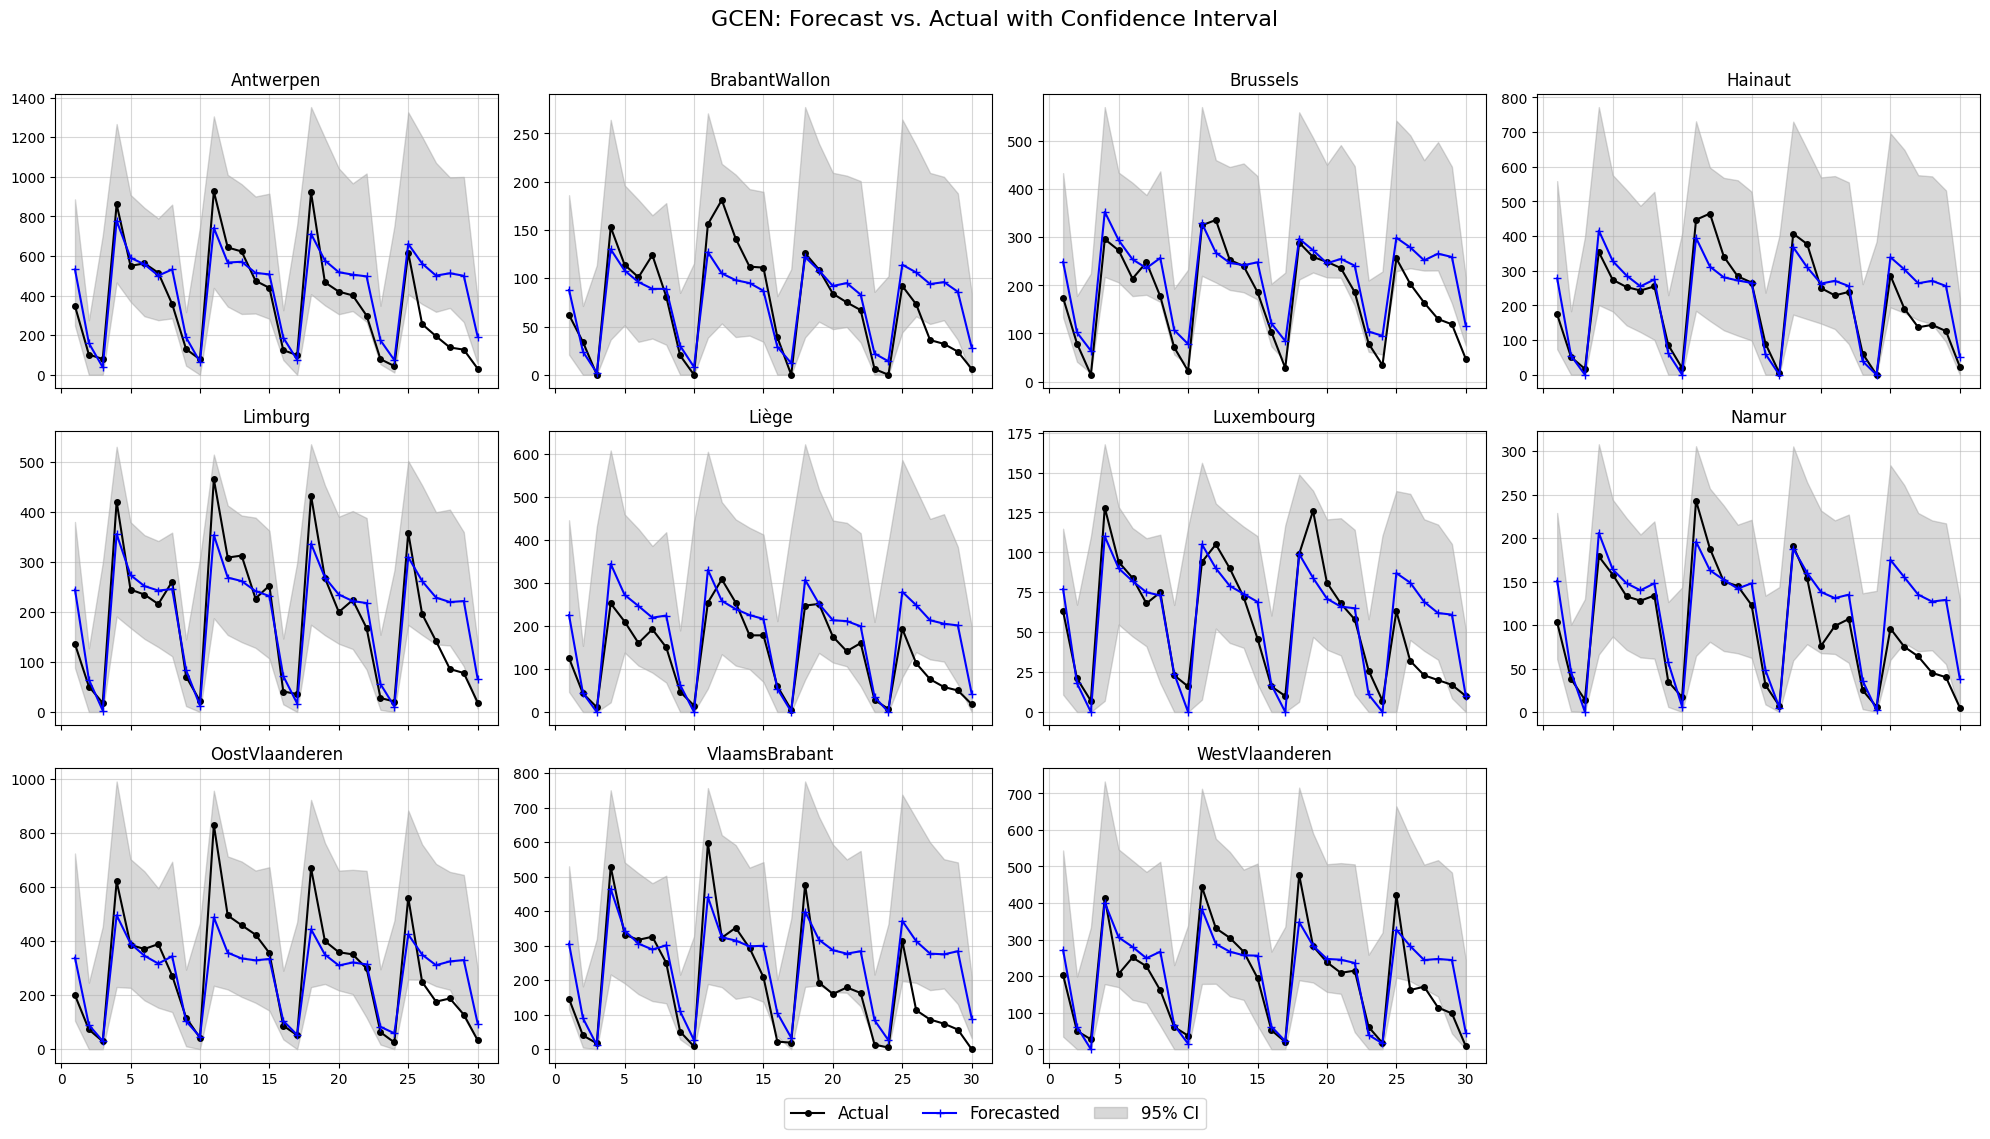

In [ ]:
forecast_ensemble = gcen.predict(test_history, m_samples = 100, unstandardize=[mean, std], device=device)
plot_forecasts(NUM_NODES, plots_per_row=4, t_pred=30, forecast_ensemble=forecast_ensemble, 
               ground_truth=test_ground_truth, confidence_level=0.95, node_names=node_names,
                   title='GCEN: Forecast vs. Actual with Confidence Interval')

## 5. STEN

Training: 100%|██████████| 100/100 [00:08<00:00, 11.42epoch/s]


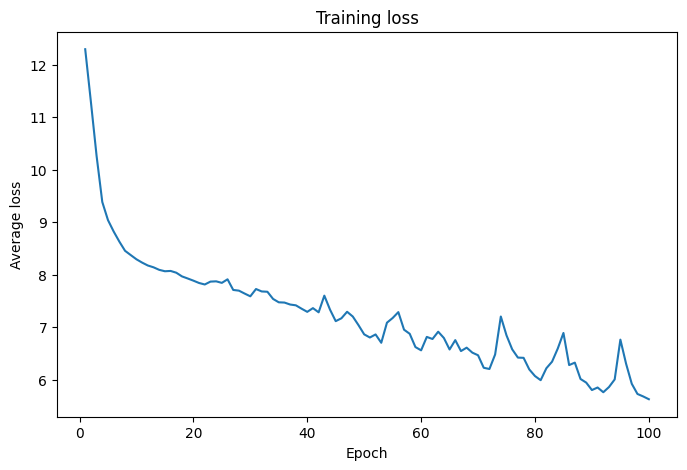

,SMAPE,MAE,RMSE,MASE,RMSSE,Pinball_80,Pinball_95,Rho-0.5,Rho-0.9,CRPS,EC,Winkler
mean,68.29,100.76,136.04,0.51,0.28,38.57,21.37,0.57,0.33,79.06,0.53,1422.45
std,0.20,0.42,0.49,0.00,0.00,0.33,0.51,0.00,0.00,0.34,0.01,33.87


In [11]:
sten = STEN(in_feat_dim=IN_FEAT_DIM, embedding_dim=10, max_spatial_lag=max_spatial_lag, num_nodes=NUM_NODES, noise_dist="uniform",
           lstm_hidden_dim=39, lstm_num_layers=1, lstm_dropout=0.2433492165113465, 
           p_lag=P_LAG, t_pred=T_PRED, temporal_seed=9).to(device)

optimizer = optim.Adam(sten.parameters(), lr=0.0016437668357369587) 

# Run Training
sten.fit(data_loader=trainloader, optimizer=optimizer, loss_fn=energy_score_loss, num_epochs=100, m_samples=2, 
         device=device, monitor=True, visualize=True, verbose=False, W_list=W_list)

metrics = sten.evaluate(m_samples=100, n_repeats=50, 
                              history=test_history, y_true=test_ground_truth, y_train=y_train, 
                              unstandardize=[mean, std], W_list=W_list)
display(metrics)

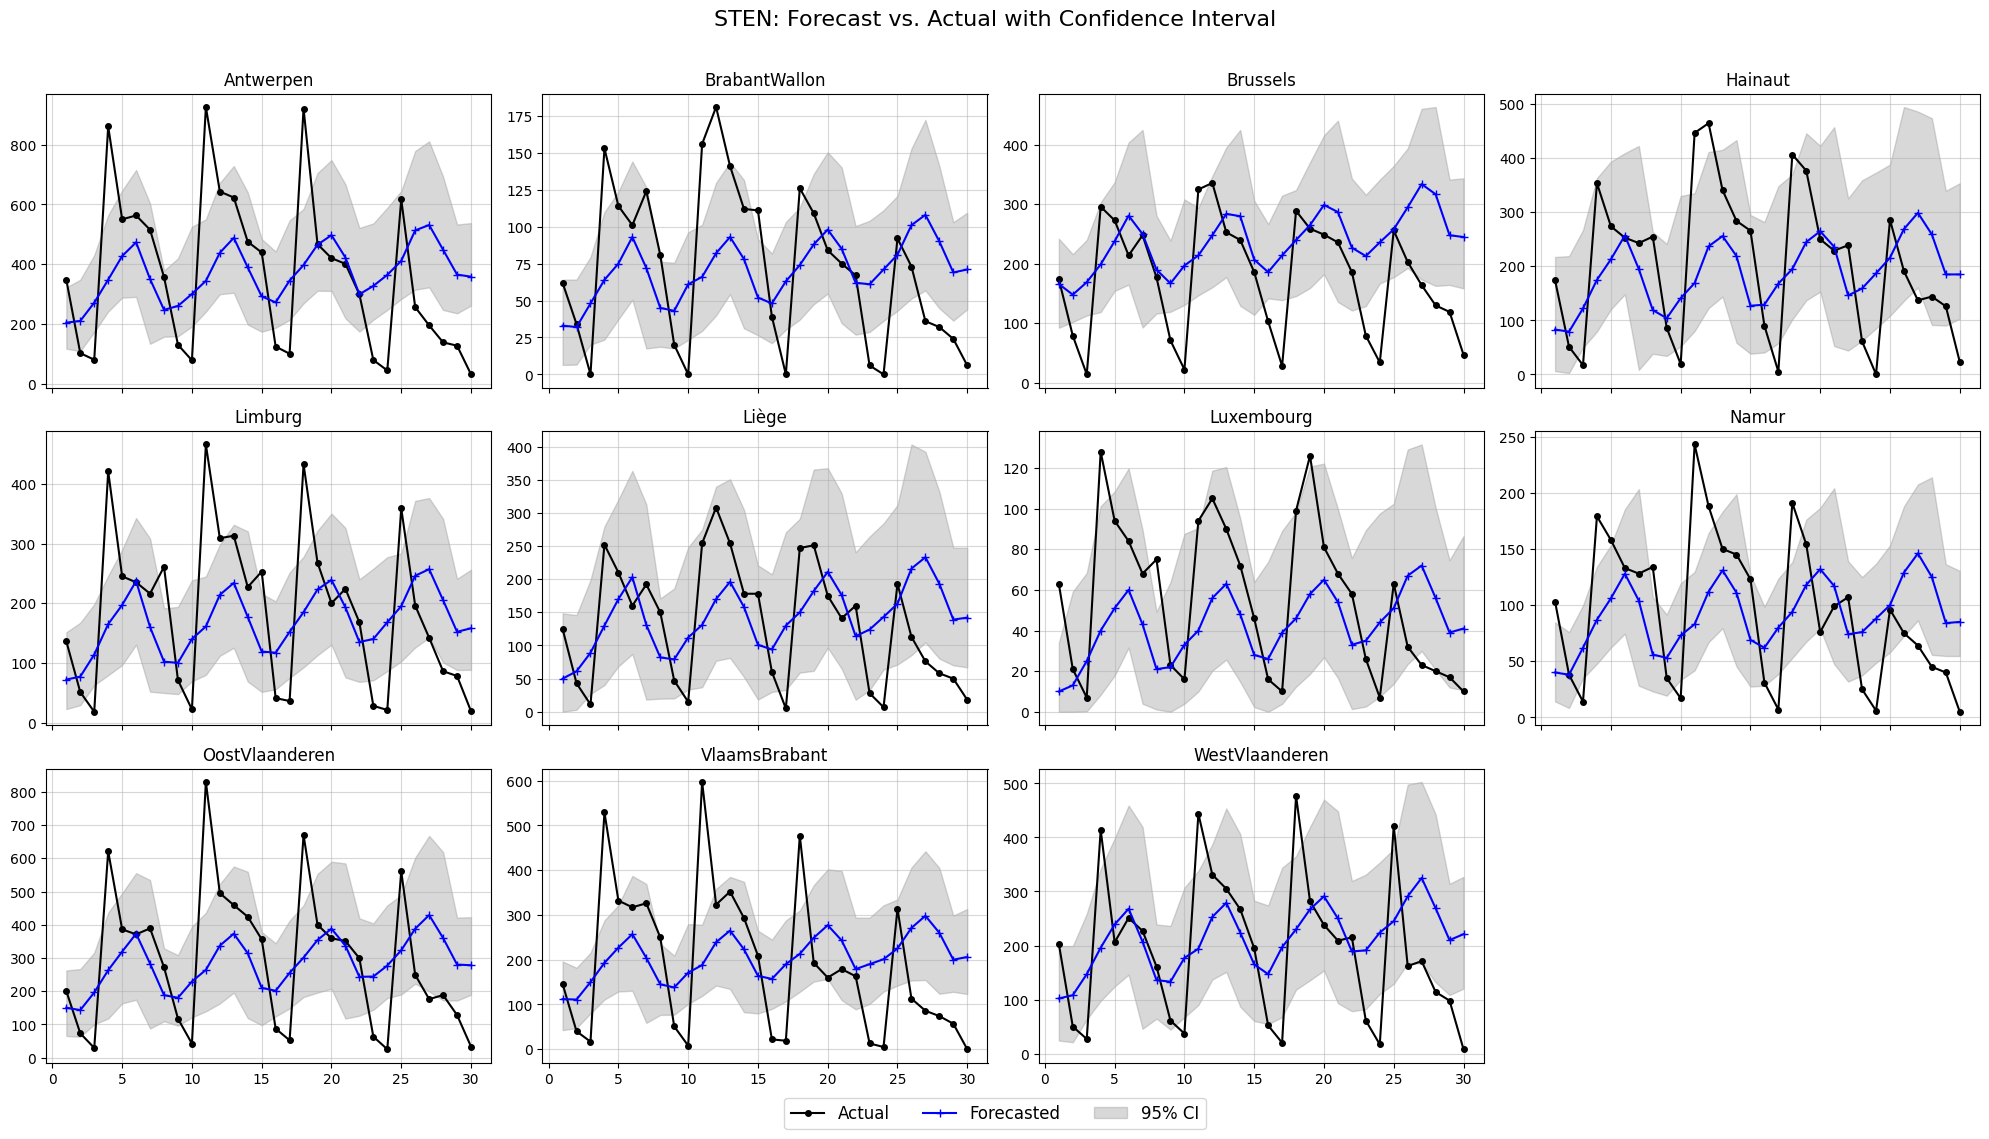

In [ ]:
forecast_ensemble = sten.predict(test_history, m_samples = 100, unstandardize=[mean, std], device=device, W_list=W_list)
plot_forecasts(NUM_NODES, plots_per_row=4, t_pred=30, forecast_ensemble=forecast_ensemble, 
               ground_truth=test_ground_truth, confidence_level=0.95, node_names=node_names,
                   title='STEN: Forecast vs. Actual with Confidence Interval')